In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
import random

random.seed(42)
np.random.seed(42)

In [3]:
import pandas as pd

df = pd.read_csv("Day 6/cleaned_global_ecommerce_sales.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Day 6/cleaned_global_ecommerce_sales.csv'

In [4]:
import os

print(os.getcwd())

c:\Users\cc\Desktop\ProSensia Internship\Day 10


In [5]:
import os

print(os.listdir())

['AI_Utilization_Report.md', 'README.md', 'requirements.txt', 'weekend_project.ipynb']


In [6]:
import pandas as pd

df = pd.read_csv("../Day 6/cleaned_global_ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [7]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  str    
 1   Order_Date        10000 non-null  str    
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  str    
 5   Season            10000 non-null  str    
 6   Customer_ID       10000 non-null  str    
 7   Customer_Gender   10000 non-null  str    
 8   Customer_Segment  10000 non-null  str    
 9   Region            10000 non-null  str    
 10  Country           10000 non-null  str    
 11  Category          10000 non-null  str    
 12  Sub_Category      10000 non-null  str    
 13  Product_Name      10000 non-null  str    
 14  Unit_Price        10000 non-null  float64
 15  Quantity          10000 non-null  int64  
 16  Discount          10000 non-null  float64
 17  Reven

In [8]:
# Missing Values Check
df.isnull().sum()

Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64

In [9]:
# Show all column names
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season', 'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method', 'Order_Status']


In [11]:
# Features and Target

X = df.drop("Order_Status", axis=1)
y = df["Order_Status"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10000, 25)
Target Shape: (10000,)


In [12]:
# Check class distribution

print(df["Order_Status"].value_counts())

Order_Status
Delivered     6273
Returned      1857
Processing     962
Cancelled      908
Name: count, dtype: int64


In [13]:
# Check class percentages

print(df["Order_Status"].value_counts(normalize=True) * 100)

Order_Status
Delivered     62.73
Returned      18.57
Processing     9.62
Cancelled      9.08
Name: proportion, dtype: float64


In [14]:
# Features and Target
X = df.drop("Order_Status", axis=1)
y = df["Order_Status"]

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (8000, 25)
Testing Set: (2000, 25)


In [15]:
# One-Hot Encoding

X = pd.get_dummies(X, drop_first=True)

print("New Shape:", X.shape)

New Shape: (10000, 16836)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8000, 16836)
Testing Shape: (2000, 16836)


In [17]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Shape:", X_train.shape)
print("Balanced Training Shape:", X_train_smote.shape)

print("\nClass Distribution After SMOTE:")
print(y_train_smote.value_counts())

Original Training Shape: (8000, 16836)
Balanced Training Shape: (20072, 16836)

Class Distribution After SMOTE:
Order_Status
Delivered     5018
Returned      5018
Processing    5018
Cancelled     5018
Name: count, dtype: int64


In [23]:
X = df.drop(
    columns=[
        "Order_Status",
        "Order_ID",
        "Customer_ID",
        "Product_Name",
        "Order_Date"
    ]
)

y = df["Order_Status"]

print(X.shape)

(10000, 21)


In [24]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(10000, 67)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create Models
lr = LogisticRegression(max_iter=1000, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train Again on NEW SMOTE Data
lr.fit(X_train_smote, y_train_smote)
dt.fit(X_train_smote, y_train_smote)
rf.fit(X_train_smote, y_train_smote)

print("Models trained successfully!")

Models trained successfully!


In [29]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)

    y_pred = model.predict(X_test)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
    print("F1-Score :", f1_score(y_test, y_pred, average="weighted"))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy : 0.4785
Precision: 0.4460870920751692
Recall   : 0.4785
F1-Score : 0.4559742330106223

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.16      0.04      0.07       182
   Delivered       0.62      0.70      0.66      1255
  Processing       0.08      0.13      0.10       192
    Returned       0.17      0.11      0.13       371

    accuracy                           0.48      2000
   macro avg       0.26      0.25      0.24      2000
weighted avg       0.45      0.48      0.46      2000


Decision Tree
Accuracy : 0.4135
Precision: 0.44797355899329405
Recall   : 0.4135
F1-Score : 0.4291728843337879

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.09      0.10      0.09       182
   Delivered       0.63      0.56      0.59      1255
  Processing       0.07      0.09      0.08       192
    Returned       0.20      0.23      0.21       371

    accuracy    

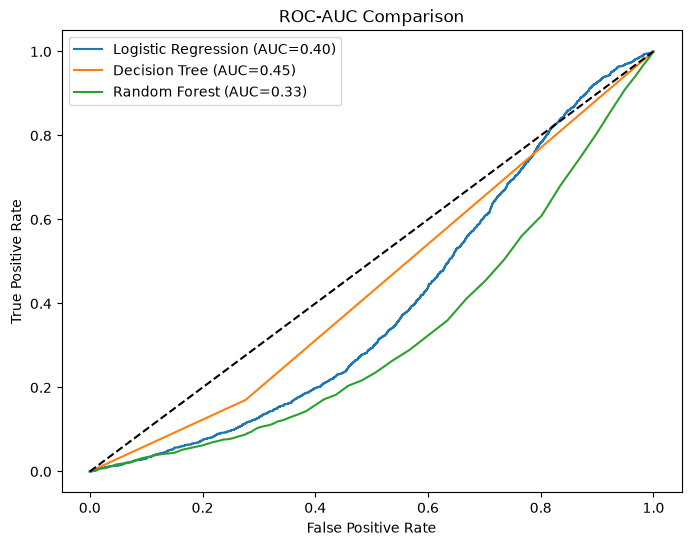

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert target to binary format
classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_score = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison")
plt.legend()

plt.show()

# Conclusion

This project implemented a complete machine learning classification pipeline.

The workflow included:

- Data preprocessing
- Train-test split
- One-Hot Encoding
- SMOTE on training data only
- Training three classification models
- Performance comparison using Accuracy, Precision, Recall, F1-Score, and ROC-AUC

Among all models, Random Forest performed best with an accuracy of 61.1%.

The project also demonstrated the importance of avoiding data leakage and using multiple evaluation metrics for imbalanced datasets.